In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
import numpy as np

#Import Data

In [ ]:
jobs = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_site_jobs.csv')
resources = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WAP_site_resources.csv')
connect = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_all_time_connect.csv')
individual = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_individual.csv')
survey = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_pulse_survey.csv')
careers = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_site_careers.csv')
other_events = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_site_other_events.csv')
programs = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_site_programs.csv')

<ipython-input-16-0e98b0a76993>:5: DtypeWarning: Columns (24,27,28,29,30,31,32,62,66,74,87) have mixed types. Specify dtype option on import or set low_memory=False.
  survey = pd.read_csv('/content/drive/My Drive/WPAC/WPA_PAC_Datacase_2025/WPA_pulse_survey.csv')


# Survey

In [ ]:
survey.head()

,version,year_quarter,children,concern_finances,concern_health,concern_job,concern_job_search,concern_social,contract_work,current_job_benefits_childcare,...,training_completed,training_enrolled,training_field,training_plan_to_enroll,training_program_provider,training_program_title,training_support_services,worked_past_six_months,years_experience,WPA_id
0,C1Q2,2023Q1,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,...,In progress (completing in next 4-6 months),Yes,NaN,No,Egan,Na,No,Yes,5-10,WPA_343
1,C1Q3,2023Q2,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,...,NaN,No,NaN,No,NaN,NaN,NaN,NaN,11-14,WPA_343
2,C1Q5,2024Q1,NaN,Extremely concerned,Slightly concerned,Slightly concerned,Slightly concerned,Extremely concerned,Yes,NaN,...,NaN,"No, did not enroll",NaN,No,NaN,NaN,NaN,NaN,11-14,WPA_343
3,C1M1,2022Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WPA_343
4,C1Q6,2024Q2,NaN,Extremely concerned,Moderately concerned,Extremely concerned,Extremely concerned,Extremely concerned,Yes,NaN,...,NaN,"No, did not enroll",New field of work,Yes,NaN,NaN,NaN,Yes,15+,WPA_343


In [ ]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19307 entries, 0 to 19306
Data columns (total 97 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   version                                       19307 non-null  object 
 1   year_quarter                                  19307 non-null  object 
 2   children                                      8639 non-null   object 
 3   concern_finances                              15045 non-null  object 
 4   concern_health                                15045 non-null  object 
 5   concern_job                                   15045 non-null  object 
 6   concern_job_search                            15045 non-null  object 
 7   concern_social                                15045 non-null  object 
 8   contract_work                                 18345 non-null  object 
 9   current_job_benefits_childcare                472 non-null   

Clean survey data
unique 'WPA_id', 'version', 'year_quarter'

In [ ]:
unique_count = survey['WPA_id'].nunique()
unique_count

10383

In [ ]:
#check duplicate
duplicate_rows = survey.duplicated()
print(duplicate_rows.sum())

0


In [ ]:
duplicate_rows = survey[survey.duplicated(subset=['WPA_id', 'version', 'year_quarter'], keep=False)]
duplicate_rows

,version,year_quarter,children,concern_finances,concern_health,concern_job,concern_job_search,concern_social,contract_work,current_job_benefits_childcare,...,training_completed,training_enrolled,training_field,training_plan_to_enroll,training_program_provider,training_program_title,training_support_services,worked_past_six_months,years_experience,WPA_id
8688,C4Q4,2024Q4,NaN,Very concerned,Moderately concerned,Slightly concerned,Moderately concerned,Moderately concerned,Yes,NaN,...,NaN,"No, did not enroll",New field of work,Yes,NaN,NaN,NaN,Yes,5-10,WPA_40524
8692,C4Q4,2024Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,WPA_40524
10933,C5Q3,2024Q4,NaN,Very concerned,Slightly concerned,Very concerned,Very concerned,Moderately concerned,Yes,Yes,...,NaN,"Yes, in progress (completing in next 0-3 months)",NaN,No,KCPS,Paraprofessional and Substitute Teacher,Yes,Yes,5-10,WPA_54999
10934,C5Q3,2024Q4,NaN,Very concerned,Very concerned,Not at all concerned,Not at all concerned,Slightly concerned,No,NaN,...,NaN,"No, did not enroll",Current field of work,Yes,NaN,NaN,NaN,NaN,2-4,WPA_54999


In [ ]:
#delete duplicate
survey_cleaned = survey.drop_duplicates(subset=['WPA_id', 'version', 'year_quarter'], keep=False)

In [ ]:
print(len(survey_cleaned))

19303


Define analysis period

In [ ]:
valid_year=['2023Q1','2023Q2','2023Q3','2023Q4','2024Q1','2024Q2','2024Q3','2024Q4']

In [ ]:
survey_period = survey_cleaned[survey_cleaned['year_quarter'].isin(valid_year)]

In [ ]:
print(len(survey_period))

18696


Define Y
(new_job,skillup_find_new_job,skillup_helpful_new_job,training_enrolled,training_completed,skillup_training,education)

In [ ]:
y = survey_period[['WPA_id', 'version', 'year_quarter','skillup_training', 'skillup_find_new_job']]

In [ ]:
y['skillup_find_new_job'].value_counts(dropna=False)

,count
skillup_find_new_job,
NaN,14689
No,3433
Yes,574


In [ ]:
y["skillup_find_new_job"]=y["skillup_find_new_job"].apply(lambda x: True if x == "Yes" else False)
y["skillup_training"]=y["skillup_training"].apply(lambda x: True if x == "Yes" else False)

<ipython-input-29-f160f87dc771>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["skillup_find_new_job"]=y["skillup_find_new_job"].apply(lambda x: True if x == "Yes" else False)
<ipython-input-29-f160f87dc771>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["skillup_training"]=y["skillup_training"].apply(lambda x: True if x == "Yes" else False)


In [ ]:
y.head()

,WPA_id,version,year_quarter,skillup_training,skillup_find_new_job
0,WPA_343,C1Q2,2023Q1,False,False
1,WPA_343,C1Q3,2023Q2,False,False
2,WPA_343,C1Q5,2024Q1,False,False
4,WPA_343,C1Q6,2024Q2,False,False
6,WPA_353,C1Q6,2024Q2,False,False


Define X

In [ ]:
x=survey_period[['WPA_id','version','year_quarter','education','desired_industry']]

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18696 entries, 0 to 19306
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   WPA_id            18696 non-null  object
 1   version           18696 non-null  object
 2   year_quarter      18696 non-null  object
 3   education         8747 non-null   object
 4   desired_industry  12199 non-null  object
dtypes: object(5)
memory usage: 1.4+ MB


In [ ]:
survey_period['education'].value_counts(dropna=False)

,count
education,
NaN,9949
Some college (no degree received),2380
"High school diploma or equivalent (GED, HSE, etc.)",2279
Four-year college degree or higher,2074
Associate’s degree,947
"Trade license or training certificate (Commercial Driver’s License (CDL), Certified Nursing Assistant (CNA), or some other kind of certificate)",690
Decline to answer,197
None of these,180


# Individual

In [ ]:
individual.head()

,rural_type,lastLoggedInAt,myPathCompleted,preferredRegion,preferredRegionGroup,createdAt,updatedAt,educationAndWorkExperience,workExperienceGroup,race,...,targetSalary,activeMilestone,completed_work_styles,retention,completed_career_milestone,completed_jobs_milestone,completed_training_milestone,gender_3,birth_year,WPA_id
0,Non-Rural,2022-05-21T02:04:38Z,NaN,Denver,Local,2022-01-11T00:18:24Z,2023-12-11T23:33:04Z,NaN,<5 years,NaN,...,NaN,careers,False,Returned,NaN,NaN,NaN,"Other, declined",NaN,WPA_1
1,Non-Rural,2022-05-23T18:51:59Z,NaN,Denver,Local,2022-01-11T00:18:24Z,2023-12-11T23:33:04Z,NaN,<5 years,NaN,...,NaN,careers,False,Returned,NaN,NaN,NaN,"Other, declined",NaN,WPA_2
2,Non-Rural,2022-05-23T19:07:13Z,NaN,Denver,Local,2022-01-11T00:18:24Z,2023-12-11T23:33:04Z,NaN,<5 years,NaN,...,NaN,careers,False,Returned,NaN,NaN,NaN,"Other, declined",NaN,WPA_3
3,Non-Rural,2024-11-25T03:41:09Z,1.0,Denver,Local,2022-01-11T00:18:24Z,2024-11-24T09:11:15Z,NaN,<5 years,White,...,61880.0,job,True,Returned,False,False,False,"Other, declined",1981.0,WPA_4
4,Non-Rural,2024-08-28T06:38:36Z,1.0,Denver,Local,2022-01-11T00:18:24Z,2024-08-22T20:01:50Z,NaN,<5 years,White,...,82490.0,training,False,Returned,False,False,False,"Other, declined",1981.0,WPA_5


In [ ]:
#check duplicate
duplicate_rows = individual.duplicated()
print(duplicate_rows.sum())

0


In [ ]:
#check duplicate 'WPA_id'
unique_count = individual['WPA_id'].nunique()
unique_count

185450

Merge Y(from Survey) and X(Demographic from individual)

In [ ]:
individual_1 = y.merge(individual, on='WPA_id', how='left')

In [ ]:
print(len(individual_1))

18696


In [ ]:
individual_1['year'] = individual_1['year_quarter'].str.extract(r'(\d{4})').astype(int)

In [ ]:
individual_1['age'] = individual_1['year'] - individual_1['birth_year']

In [ ]:
individual_1=individual_1[['WPA_id','rural_type','myPathCompleted','preferredRegion','preferredRegionGroup','educationAndWorkExperience','workExperienceGroup','race','highestEducationLevel','latestSalary','targetSalary','activeMilestone','completed_career_milestone','completed_jobs_milestone','completed_training_milestone','gender_3','age']]

In [ ]:
individual_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   WPA_id                        18696 non-null  object 
 1   rural_type                    17311 non-null  object 
 2   myPathCompleted               15784 non-null  float64
 3   preferredRegion               18694 non-null  object 
 4   preferredRegionGroup          18696 non-null  object 
 5   educationAndWorkExperience    13834 non-null  object 
 6   workExperienceGroup           18696 non-null  object 
 7   race                          15897 non-null  object 
 8   highestEducationLevel         13593 non-null  object 
 9   latestSalary                  1782 non-null   float64
 10  targetSalary                  1645 non-null   float64
 11  activeMilestone               18695 non-null  object 
 12  completed_career_milestone    7857 non-null   object 
 13  c

# All time connect

In [ ]:
connect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895858 entries, 0 to 895857
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   _id              895858 non-null  object
 1   collectionType   890889 non-null  object
 2   eventName        895858 non-null  object
 3   createdAt        895858 non-null  object
 4   partnerRegion    889466 non-null  object
 5   sessionId        719305 non-null  object
 6   data_careerId    170748 non-null  object
 7   data_jobId       310011 non-null  object
 8   data_programId   391244 non-null  object
 9   data_resourceId  19859 non-null   object
 10  WPA_id           895858 non-null  object
dtypes: object(11)
memory usage: 75.2+ MB


In [ ]:
from datetime import datetime

In [ ]:
connect['date_part'] = connect['createdAt'].str.split("T").str[0]

In [ ]:
connect.head()

,_id,collectionType,eventName,createdAt,partnerRegion,sessionId,data_careerId,data_jobId,data_programId,data_resourceId,WPA_id,date_part
0,643d44f5464a935da1b35d78,resources,saved catalog item,2023-04-17T13:09:10Z,NaN,NaN,NaN,NaN,NaN,63e53d123f747a7a197b980e,WPA_303,2023-04-17
1,66c4eb770b452dc562a690f2,training,viewed a catalog item,2024-08-20T23:16:07Z,Los Angeles,91af41c2-84ac-43ea-a0d1-a5148bd28f57,NaN,NaN,6386d2df79cd1ed0d4b4aa2f,NaN,WPA_303,2024-08-20
2,66c4fa3d0b452dc562a97b10,training,clicked apply,2024-08-21T00:19:09Z,Los Angeles,91af41c2-84ac-43ea-a0d1-a5148bd28f57,NaN,NaN,6566894bea01e4f9bf3a86e6,NaN,WPA_303,2024-08-21
3,65ef646edef3317e0f65ea55,jobs,viewed a catalog item,2024-03-12T00:07:10Z,New York City,912440d6-4c59-4bd8-bdb5-8329a8d61bb0,NaN,54cba485004b779b1388b4ab094c15502df09265,NaN,NaN,WPA_303,2024-03-12
4,63fe924e16d0e616d4a7b76a,jobs,saved catalog item,2023-02-28T13:46:23Z,Louisiana,NaN,NaN,39393216969,NaN,NaN,WPA_303,2023-02-28


In [ ]:
survey_mapping = {
    'C1M1': '2022-12-01', 'C1Q2': '2023-03-01', 'C1Q3': '2023-06-01', 'C1Q4': '2023-10-01',
    'C1Q5': '2024-01-01', 'C1Q6': '2024-05-01', 'C1Q7': '2024-09-01', 'C1Q8': '2025-01-01',

    'C2Q1': '2023-03-01', 'C2Q2': '2023-06-01', 'C2Q3': '2023-10-01', 'C2Q4': '2024-01-01',
    'C2Q5': '2024-05-01', 'C2Q6': '2024-09-01', 'C2Q7': '2025-01-01', 'C2Q8': '2025-05-01',

    'C3Q1': '2023-06-01', 'C3Q2': '2023-10-01', 'C3Q3': '2024-01-01', 'C3Q4': '2024-05-01',
    'C3Q5': '2024-09-01', 'C3Q6': '2025-01-01', 'C3Q7': '2025-05-01', 'C3Q8': '2025-09-01',

    'C4Q1': '2023-10-01', 'C4Q2': '2024-01-01', 'C4Q3': '2024-05-01', 'C4Q4': '2024-09-01',
    'C4Q5': '2025-01-01', 'C4Q6': '2025-05-01', 'C4Q7': '2025-09-01', 'C4Q8': '2026-01-01',

    'C5Q1': '2024-01-01', 'C5Q2': '2024-05-01', 'C5Q3': '2024-09-01', 'C5Q4': '2025-01-01',
    'C5Q5': '2025-05-01', 'C5Q6': '2025-09-01', 'C5Q7': '2026-01-01', 'C5Q8': '2026-05-01',

    'C6Q1': '2024-05-01', 'C6Q2': '2024-09-01', 'C6Q3': '2025-01-01', 'C6Q4': '2025-05-01',
    'C6Q5': '2025-09-01', 'C6Q6': '2026-01-01', 'C6Q7': '2026-05-01', 'C6Q8': '2026-09-01',
}

In [ ]:
y['survey_date'] = y['version'].map(survey_mapping)

<ipython-input-48-fa6d9be05286>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['survey_date'] = y['version'].map(survey_mapping)


In [ ]:
y.head()

,WPA_id,version,year_quarter,skillup_training,skillup_find_new_job,survey_date
0,WPA_343,C1Q2,2023Q1,False,False,2023-03-01
1,WPA_343,C1Q3,2023Q2,False,False,2023-06-01
2,WPA_343,C1Q5,2024Q1,False,False,2024-01-01
4,WPA_343,C1Q6,2024Q2,False,False,2024-05-01
6,WPA_353,C1Q6,2024Q2,False,False,2024-05-01


In [ ]:
y['survey_date'] = pd.to_datetime(y['survey_date'])
connect['date_part'] = pd.to_datetime(connect['date_part'])

<ipython-input-50-f5366bccfe62>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['survey_date'] = pd.to_datetime(y['survey_date'])


In [ ]:
connect_n=connect[['date_part','WPA_id']]

In [ ]:
connect_n1 = y.merge(connect_n, on='WPA_id', how='left')

In [ ]:
connect_n1['date_part_plus_180'] = connect_n1['date_part'] + pd.Timedelta(days=180)

In [ ]:
connect_n1 = connect_n1[connect_n1['survey_date'] > connect_n1['date_part_plus_180']]

In [ ]:
connect_n1 = connect_n1.groupby(['WPA_id', 'version']).size().reset_index(name='count')

In [ ]:
connect_n1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5105 entries, 0 to 5104
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   WPA_id   5105 non-null   object
 1   version  5105 non-null   object
 2   count    5105 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 119.8+ KB


In [ ]:
connect_n1.head()

,WPA_id,version,count
0,WPA_10001,C1Q4,1
1,WPA_10001,C1Q5,1
2,WPA_10001,C1Q6,1
3,WPA_10001,C1Q7,4
4,WPA_10013,C1Q5,2


In [ ]:
connect_p=connect[['date_part','WPA_id','data_programId','collectionType','eventName']]

In [ ]:
connect_p.head()

,date_part,WPA_id,data_programId,collectionType,eventName
0,2023-04-17,WPA_303,NaN,resources,saved catalog item
1,2024-08-20,WPA_303,6386d2df79cd1ed0d4b4aa2f,training,viewed a catalog item
2,2024-08-21,WPA_303,6566894bea01e4f9bf3a86e6,training,clicked apply
3,2024-03-12,WPA_303,NaN,jobs,viewed a catalog item
4,2023-02-28,WPA_303,NaN,jobs,saved catalog item


In [ ]:
connect_p['collectionType'].value_counts(dropna=False)

,count
collectionType,
training,384484
jobs,309808
careers,176608
resources,19989
NaN,4969


In [ ]:
connect_p['eventName'].value_counts(dropna=False)

,count
eventName,
saved catalog item,353658
viewed a catalog item,351506
clicked apply,180092
edited status,10576
clicked on a resource,26


In [ ]:
connect_p["collection_event"] = connect_p["collectionType"].str.cat(connect_p["eventName"], sep="_")

<ipython-input-62-869083e73eec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  connect_p["collection_event"] = connect_p["collectionType"].str.cat(connect_p["eventName"], sep="_")


In [ ]:
connect_p['collection_event'].value_counts(dropna=False)

,count
collection_event,
training_saved catalog item,160992
jobs_viewed a catalog item,149013
training_viewed a catalog item,126153
careers_saved catalog item,100268
training_clicked apply,93529
jobs_clicked apply,86563
careers_viewed a catalog item,76340
jobs_saved catalog item,72435
resources_saved catalog item,19963


In [ ]:
connect_p["collection_event"] = connect_p["collectionType"].fillna("missing").str.cat(
    connect_p["eventName"].fillna("missing"), sep="_"
)

connect_p_dummies = pd.get_dummies(connect_p, columns=["collection_event"], prefix="event")


connect_p_dummies.head()


<ipython-input-64-2f5fad85d2e8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  connect_p["collection_event"] = connect_p["collectionType"].fillna("missing").str.cat(


,date_part,WPA_id,data_programId,collectionType,eventName,event_careers_saved catalog item,event_careers_viewed a catalog item,event_jobs_clicked apply,event_jobs_edited status,event_jobs_saved catalog item,event_jobs_viewed a catalog item,event_missing_edited status,event_resources_clicked on a resource,event_resources_saved catalog item,event_training_clicked apply,event_training_edited status,event_training_saved catalog item,event_training_viewed a catalog item
0,2023-04-17,WPA_303,NaN,resources,saved catalog item,False,False,False,False,False,False,False,False,True,False,False,False,False
1,2024-08-20,WPA_303,6386d2df79cd1ed0d4b4aa2f,training,viewed a catalog item,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2024-08-21,WPA_303,6566894bea01e4f9bf3a86e6,training,clicked apply,False,False,False,False,False,False,False,False,False,True,False,False,False
3,2024-03-12,WPA_303,NaN,jobs,viewed a catalog item,False,False,False,False,False,True,False,False,False,False,False,False,False
4,2023-02-28,WPA_303,NaN,jobs,saved catalog item,False,False,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
connect_n2 = y.merge(connect_p_dummies, on='WPA_id', how='left')
connect_n2['date_part_plus_180'] = connect_n2['date_part'] + pd.Timedelta(days=180)
connect_n2 = connect_n2[connect_n2['survey_date'] > connect_n2['date_part_plus_180']]

In [ ]:
connect_n2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31521 entries, 52 to 123394
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   WPA_id                                 31521 non-null  object        
 1   version                                31521 non-null  object        
 2   year_quarter                           31521 non-null  object        
 3   skillup_training                       31521 non-null  bool          
 4   skillup_find_new_job                   31521 non-null  bool          
 5   survey_date                            31521 non-null  datetime64[ns]
 6   date_part                              31521 non-null  datetime64[ns]
 7   data_programId                         19956 non-null  object        
 8   collectionType                         31521 non-null  object        
 9   eventName                              31521 non-null  object   

In [ ]:
event_columns = [
    "event_careers_saved catalog item", "event_careers_viewed a catalog item",
    "event_jobs_clicked apply", "event_jobs_edited status", "event_jobs_saved catalog item",
    "event_jobs_viewed a catalog item", "event_missing_edited status",
    "event_resources_clicked on a resource", "event_resources_saved catalog item",
    "event_training_clicked apply", "event_training_edited status",
    "event_training_saved catalog item", "event_training_viewed a catalog item"
]


connect_n2[event_columns] = connect_n2[event_columns].apply(pd.to_numeric, errors='coerce').fillna(0)


grouped_connect_n2 = connect_n2.groupby(['WPA_id', 'version'])[event_columns].sum().reset_index()


for col in event_columns:
    grouped_connect_n2[col + "_binary"] = (grouped_connect_n2[col] >= 1).astype(int)

grouped_connect_n2 = grouped_connect_n2.drop(columns=event_columns)


grouped_connect_n2.head()

,WPA_id,version,event_careers_saved catalog item_binary,event_careers_viewed a catalog item_binary,event_jobs_clicked apply_binary,event_jobs_edited status_binary,event_jobs_saved catalog item_binary,event_jobs_viewed a catalog item_binary,event_missing_edited status_binary,event_resources_clicked on a resource_binary,event_resources_saved catalog item_binary,event_training_clicked apply_binary,event_training_edited status_binary,event_training_saved catalog item_binary,event_training_viewed a catalog item_binary
0,WPA_10001,C1Q4,0,0,0,0,0,0,0,0,0,1,0,0,0
1,WPA_10001,C1Q5,0,0,0,0,0,0,0,0,0,1,0,0,0
2,WPA_10001,C1Q6,0,0,0,0,0,0,0,0,0,1,0,0,0
3,WPA_10001,C1Q7,0,0,0,0,0,0,0,0,0,1,0,1,1
4,WPA_10013,C1Q5,1,0,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
grouped_connect_n2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5105 entries, 0 to 5104
Data columns (total 15 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   WPA_id                                        5105 non-null   object
 1   version                                       5105 non-null   object
 2   event_careers_saved catalog item_binary       5105 non-null   int64 
 3   event_careers_viewed a catalog item_binary    5105 non-null   int64 
 4   event_jobs_clicked apply_binary               5105 non-null   int64 
 5   event_jobs_edited status_binary               5105 non-null   int64 
 6   event_jobs_saved catalog item_binary          5105 non-null   int64 
 7   event_jobs_viewed a catalog item_binary       5105 non-null   int64 
 8   event_missing_edited status_binary            5105 non-null   int64 
 9   event_resources_clicked on a resource_binary  5105 non-null   int64 
 10  

#Descriptive Analysis: Correlation analysis, Chi-Square Test

In [ ]:
individual_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   WPA_id                        18696 non-null  object 
 1   rural_type                    17311 non-null  object 
 2   myPathCompleted               15784 non-null  float64
 3   preferredRegion               18694 non-null  object 
 4   preferredRegionGroup          18696 non-null  object 
 5   educationAndWorkExperience    13834 non-null  object 
 6   workExperienceGroup           18696 non-null  object 
 7   race                          15897 non-null  object 
 8   highestEducationLevel         13593 non-null  object 
 9   latestSalary                  1782 non-null   float64
 10  targetSalary                  1645 non-null   float64
 11  activeMilestone               18695 non-null  object 
 12  completed_career_milestone    7857 non-null   object 
 13  c

In [ ]:
individual_2 = individual_1.drop_duplicates(subset=['WPA_id'])

In [ ]:
xx = x.merge(individual_2, on='WPA_id', how='left')

In [ ]:
xx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   WPA_id                        18696 non-null  object 
 1   version                       18696 non-null  object 
 2   year_quarter                  18696 non-null  object 
 3   education                     8747 non-null   object 
 4   desired_industry              12199 non-null  object 
 5   rural_type                    17311 non-null  object 
 6   myPathCompleted               15784 non-null  float64
 7   preferredRegion               18694 non-null  object 
 8   preferredRegionGroup          18696 non-null  object 
 9   educationAndWorkExperience    13834 non-null  object 
 10  workExperienceGroup           18696 non-null  object 
 11  race                          15897 non-null  object 
 12  highestEducationLevel         13593 non-null  object 
 13  l

In [ ]:
connect_n2 = connect_n1.drop_duplicates(subset=['WPA_id','version'])

In [ ]:
xx1 = xx.merge(connect_n2, on=['WPA_id','version'], how='left')

In [ ]:
xx1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   WPA_id                        18696 non-null  object 
 1   version                       18696 non-null  object 
 2   year_quarter                  18696 non-null  object 
 3   education                     8747 non-null   object 
 4   desired_industry              12199 non-null  object 
 5   rural_type                    17311 non-null  object 
 6   myPathCompleted               15784 non-null  float64
 7   preferredRegion               18694 non-null  object 
 8   preferredRegionGroup          18696 non-null  object 
 9   educationAndWorkExperience    13834 non-null  object 
 10  workExperienceGroup           18696 non-null  object 
 11  race                          15897 non-null  object 
 12  highestEducationLevel         13593 non-null  object 
 13  l

In [ ]:
grouped_connect_n3 = grouped_connect_n2.drop_duplicates(subset=['WPA_id','version'])

In [ ]:
xx2 = xx1.merge(grouped_connect_n3, on=['WPA_id','version'], how='left')

In [ ]:
xy = xx2.merge(y, on=['WPA_id','version'], how='left')

In [ ]:
xy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   WPA_id                                        18696 non-null  object        
 1   version                                       18696 non-null  object        
 2   year_quarter_x                                18696 non-null  object        
 3   education                                     8747 non-null   object        
 4   desired_industry                              12199 non-null  object        
 5   rural_type                                    17311 non-null  object        
 6   myPathCompleted                               15784 non-null  float64       
 7   preferredRegion                               18694 non-null  object        
 8   preferredRegionGroup                          18696 non-null  obje

In [ ]:
df = xy.drop(columns=['WPA_id','version','year_quarter_y','year_quarter_x'])

In [ ]:
df['completed_career_milestone'].value_counts(dropna=False)

,count
completed_career_milestone,
NaN,10839
False,6507
True,1350


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 35 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   education                                     8747 non-null   object        
 1   desired_industry                              12199 non-null  object        
 2   rural_type                                    17311 non-null  object        
 3   myPathCompleted                               15784 non-null  float64       
 4   preferredRegion                               18694 non-null  object        
 5   preferredRegionGroup                          18696 non-null  object        
 6   educationAndWorkExperience                    13834 non-null  object        
 7   workExperienceGroup                           18696 non-null  object        
 8   race                                          15897 non-null  obje

In [ ]:
binary_columns = [
    "event_careers_saved catalog item_binary", "event_careers_viewed a catalog item_binary",
    "event_jobs_clicked apply_binary", "event_jobs_edited status_binary",
    "event_jobs_saved catalog item_binary", "event_jobs_viewed a catalog item_binary",
    "event_missing_edited status_binary", "event_resources_clicked on a resource_binary",
    "event_resources_saved catalog item_binary", "event_training_clicked apply_binary",
    "event_training_edited status_binary", "event_training_saved catalog item_binary",
    "event_training_viewed a catalog item_binary"
]


df[binary_columns] = df[binary_columns].astype('category')


df[binary_columns].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 13 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   event_careers_saved catalog item_binary       5105 non-null   category
 1   event_careers_viewed a catalog item_binary    5105 non-null   category
 2   event_jobs_clicked apply_binary               5105 non-null   category
 3   event_jobs_edited status_binary               5105 non-null   category
 4   event_jobs_saved catalog item_binary          5105 non-null   category
 5   event_jobs_viewed a catalog item_binary       5105 non-null   category
 6   event_missing_edited status_binary            5105 non-null   category
 7   event_resources_clicked on a resource_binary  5105 non-null   category
 8   event_resources_saved catalog item_binary     5105 non-null   category
 9   event_training_clicked apply_binary           5105

In [ ]:
# Define the rename dictionary
rename_dict = {
    "event_careers_saved catalog item_binary": "Careers Saved Catalog Item",
    "event_careers_viewed a catalog item_binary": "Careers Viewed Catalog Item",
    "event_jobs_clicked apply_binary": "Jobs Clicked Apply",
    "event_jobs_edited status_binary": "Jobs Edited Status",
    "event_jobs_saved catalog item_binary": "Jobs Saved Catalog Item",
    "event_jobs_viewed a catalog item_binary": "Jobs Viewed Catalog Item",
    "event_missing_edited status_binary": "Missing Edited Status",
    "event_resources_clicked on a resource_binary": "Resources Clicked on a Resource",
    "event_resources_saved catalog item_binary": "Resources Saved Catalog Item",
    "event_training_clicked apply_binary": "Training Clicked Apply",
    "event_training_edited status_binary": "Training Edited Status",
    "event_training_saved catalog item_binary": "Training Saved Catalog Item",
    "event_training_viewed a catalog item_binary": "Training Viewed Catalog Item",
    "race": "Race",
    "gender_3": "Gender",
    "educationAndWorkExperience": "Education And Work Experience",
    "preferredRegion": "Preferred Region",
    "desired_industry": "Desired Industry",
    "workExperienceGroup": "Work Experience Group",
    "highestEducationLevel": "Highest Education Level",
    "completed_training_milestone": "Completed Training Milestone",
    "activeMilestone": "Active Milestone",
    "completed_jobs_milestone": "Completed Jobs Milestone",
    "rural_type": "Rural Type",
    "completed_career_milestone": "Completed Career Milestone",
    "preferredRegionGroup": "Preferred Region Group",
    "age": "Age",
    "count": "Website Visits (Last 180 Days)"

}

# Rename the specified columns in the existing dataframe
df.rename(columns=rename_dict, inplace=True)

# Display the updated dataframe structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   education                        8747 non-null   object        
 1   Desired Industry                 12199 non-null  object        
 2   Rural Type                       17311 non-null  object        
 3   myPathCompleted                  15784 non-null  float64       
 4   Preferred Region                 18694 non-null  object        
 5   Preferred Region Group           18696 non-null  object        
 6   Education And Work Experience    13834 non-null  object        
 7   Work Experience Group            18696 non-null  object        
 8   Race                             15897 non-null  object        
 9   Highest Education Level          13593 non-null  object        
 10  latestSalary                     1782 non-null   float64  

In [ ]:
df = df.drop(columns=['Active Milestone', 'education'])

In [ ]:
df['skillup_training'].value_counts(dropna=False)

,count
skillup_training,
False,17579
True,1117


In [ ]:
df['skillup_find_new_job'].value_counts(dropna=False)

,count
skillup_find_new_job,
False,18122
True,574


Chiq test skillup_training

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Desired Industry                 12199 non-null  object        
 1   Rural Type                       17311 non-null  object        
 2   myPathCompleted                  15784 non-null  float64       
 3   Preferred Region                 18694 non-null  object        
 4   Preferred Region Group           18696 non-null  object        
 5   Education And Work Experience    13834 non-null  object        
 6   Work Experience Group            18696 non-null  object        
 7   Race                             15897 non-null  object        
 8   Highest Education Level          13593 non-null  object        
 9   latestSalary                     1782 non-null   float64       
 10  targetSalary                     1645 non-null   float64  

In [ ]:
from scipy.stats import chi2_contingency


cat_columns = df.select_dtypes(exclude=['number', 'bool', 'datetime']).columns

chi2_results = []
for col in cat_columns:
    contingency_table = pd.crosstab(df[col], df['skillup_training'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append((col, chi2, p))


chi2_df = pd.DataFrame(chi2_results, columns=['Variable', 'Chi2', 'p-value']).sort_values(by='Chi2', ascending=False)
chi2_df['p-value'] = chi2_df['p-value'].apply(lambda x: format(x, '.4f'))

from IPython.display import display
display(chi2_df)



,Variable,Chi2,p-value
6,Race,115.599996,0.0000
11,Gender,75.572938,0.0000
4,Education And Work Experience,61.664660,0.0000
2,Preferred Region,59.011716,0.0005
0,Desired Industry,41.201013,0.0000
5,Work Experience Group,35.335590,0.0000
7,Highest Education Level,30.637029,0.0000
10,Completed Training Milestone,23.045119,0.0000
9,Completed Jobs Milestone,18.104876,0.0000
21,Training Clicked Apply,13.429906,0.0002


Chiq test skillup_find_new_job

In [ ]:
cat_columns = df.select_dtypes(exclude=['number', 'bool', 'datetime']).columns

chi2_results = []
for col in cat_columns:
    contingency_table = pd.crosstab(df[col], df['skillup_find_new_job'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append((col, chi2, p))


chi2_df = pd.DataFrame(chi2_results, columns=['Variable', 'Chi2', 'p-value']).sort_values(by='Chi2', ascending=False)
chi2_df['p-value'] = chi2_df['p-value'].apply(lambda x: format(x, '.4f'))

from IPython.display import display
display(chi2_df)



,Variable,Chi2,p-value
11,Gender,130.059252,0.0000
6,Race,68.689952,0.0000
7,Highest Education Level,64.900578,0.0000
4,Education And Work Experience,56.421462,0.0000
2,Preferred Region,46.597776,0.0151
0,Desired Industry,44.783210,0.0000
14,Jobs Clicked Apply,7.685240,0.0056
10,Completed Training Milestone,7.453410,0.0063
1,Rural Type,5.148965,0.0233
13,Careers Viewed Catalog Item,5.107950,0.0238


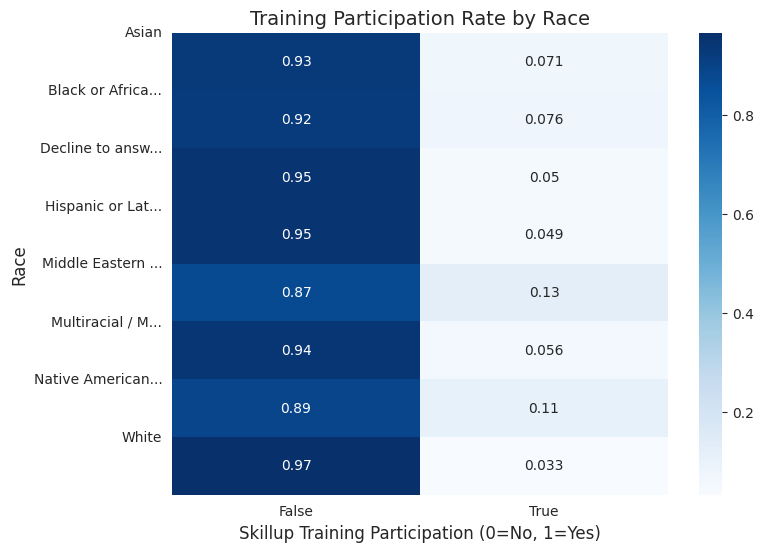

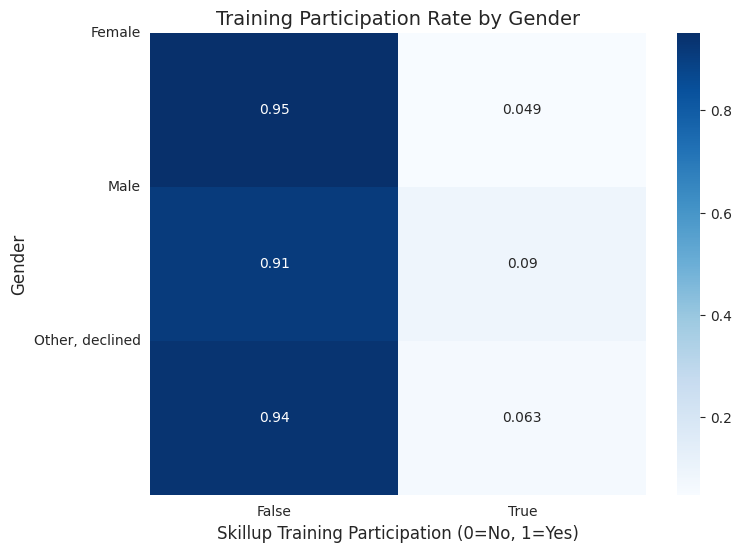

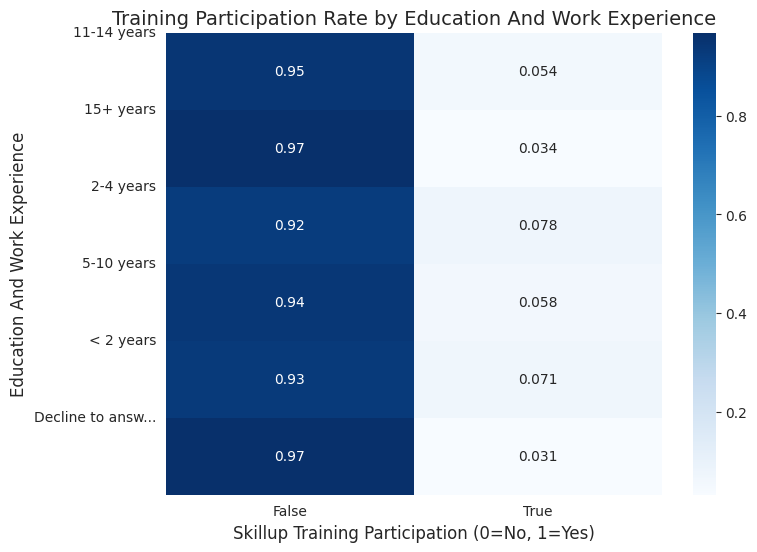

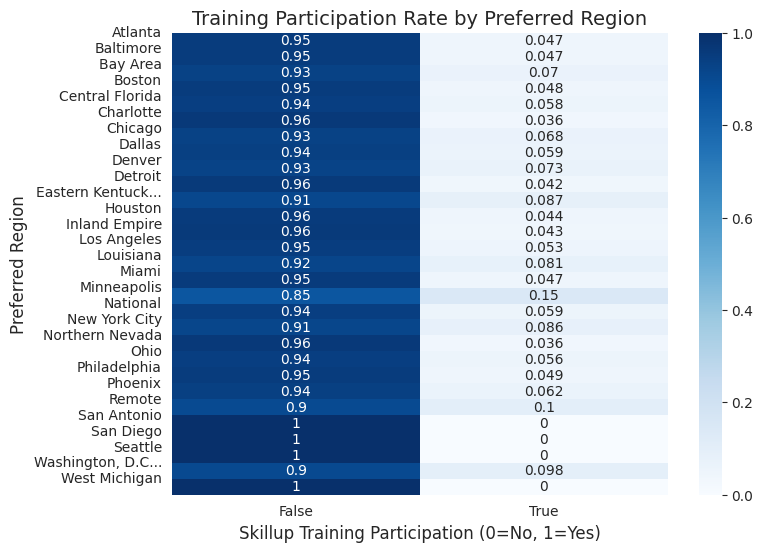

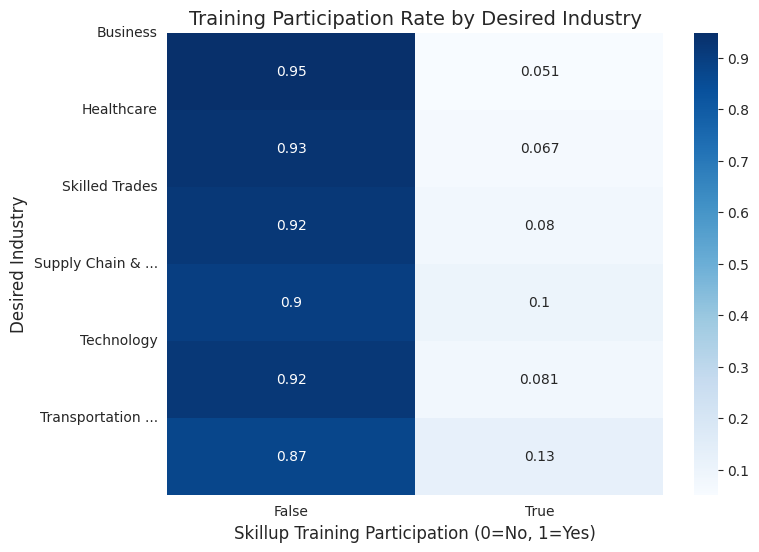

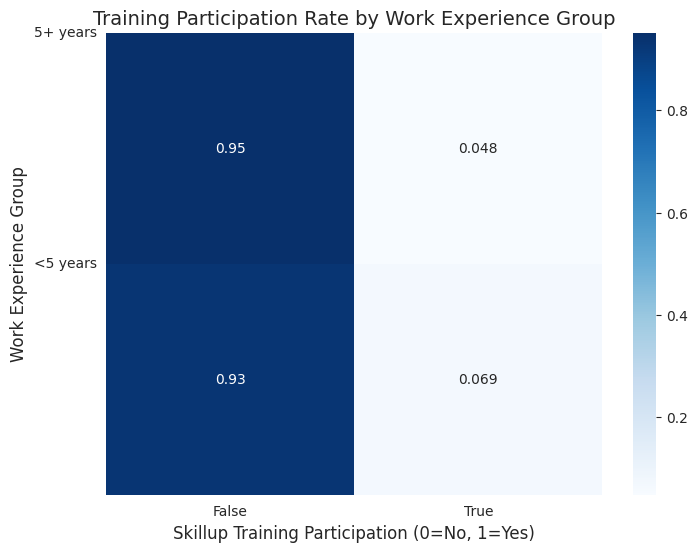

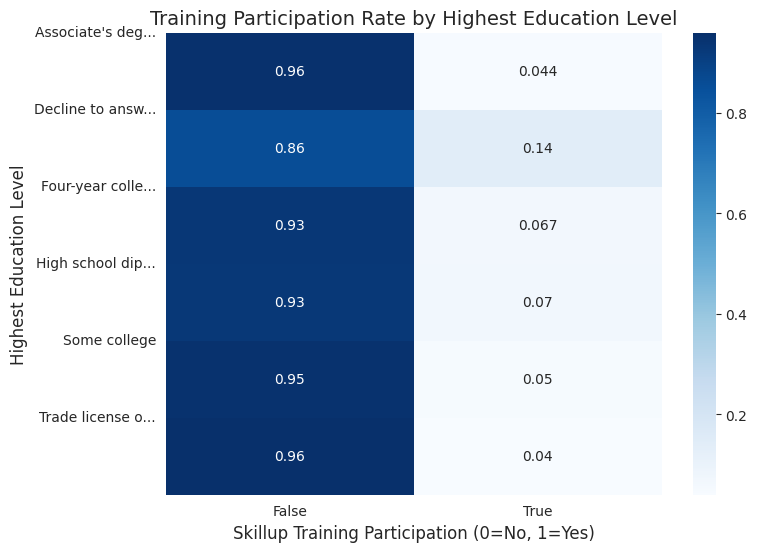

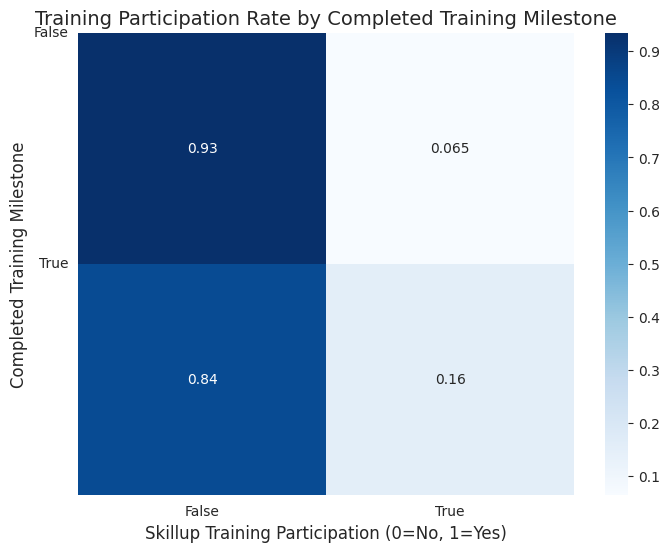

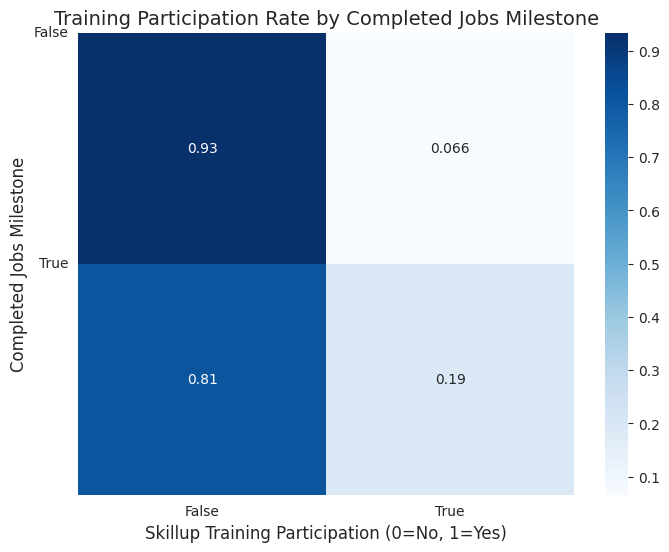

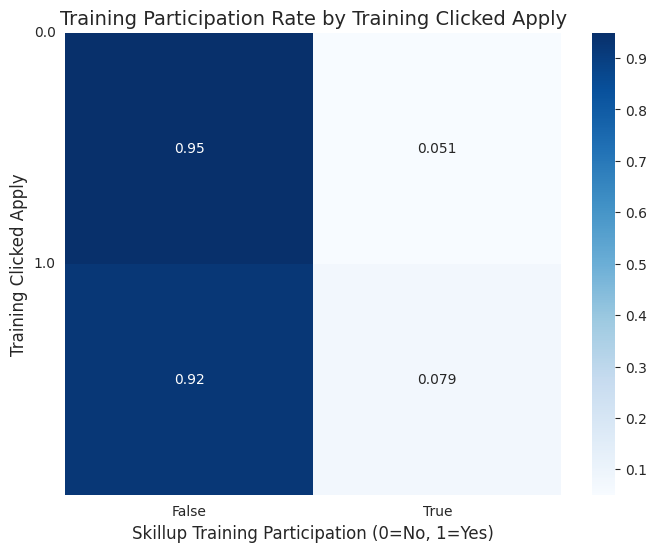

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define categorical features
categorical_features = [
    'Race', 'Gender', 'Education And Work Experience', 'Preferred Region',
    'Desired Industry', 'Work Experience Group', 'Highest Education Level',
    'Completed Training Milestone', 'Completed Jobs Milestone', 'Training Clicked Apply'
]

# Generate individual heatmaps
for feature in categorical_features:
    plt.figure(figsize=(8, 6))  # Set individual figure size

    crosstab = pd.crosstab(df[feature], df['skillup_training'], normalize='index')

    # Create heatmap
    sns.heatmap(crosstab, annot=True, cmap="Blues")

    # Set titles and labels
    plt.title(f"Training Participation Rate by {feature}", fontsize=14)
    plt.xlabel("Skillup Training Participation (0=No, 1=Yes)", fontsize=12)
    plt.ylabel(feature, fontsize=12)

    # Adjust y-axis labels for readability
    plt.yticks(
        range(len(crosstab.index)),
        [str(label)[:15] + '...' if len(str(label)) > 15 else str(label) for label in crosstab.index],
        rotation=0
    )

    plt.show()  # Display each plot separately


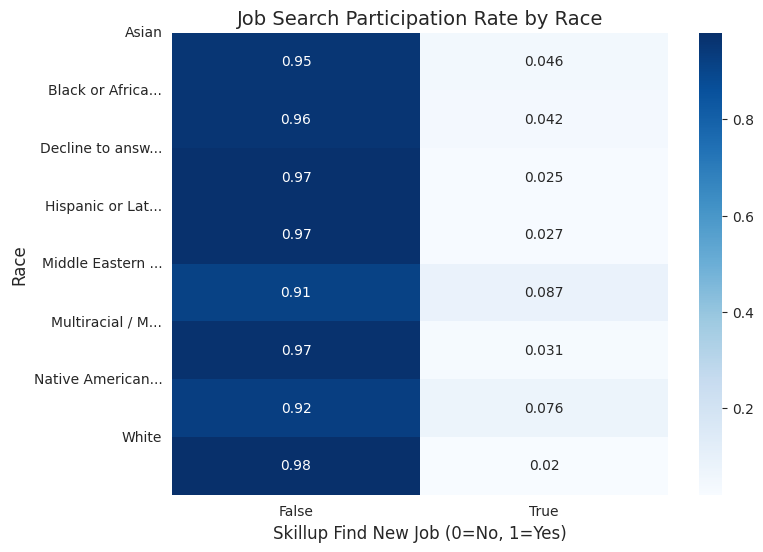

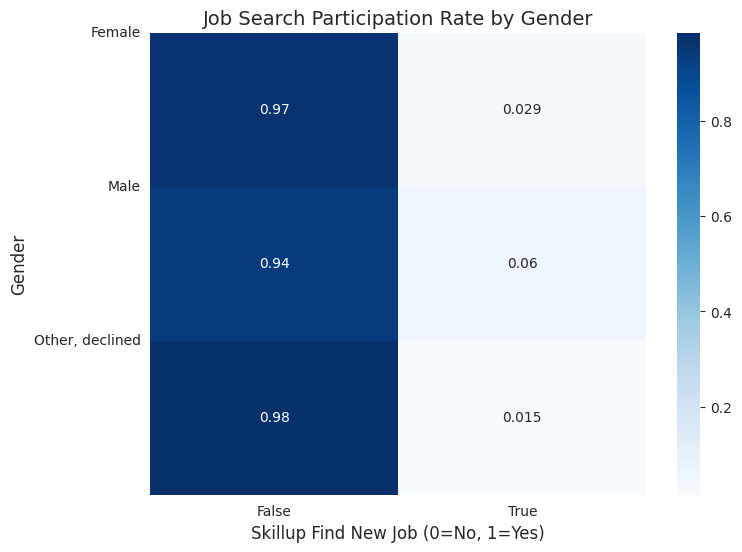

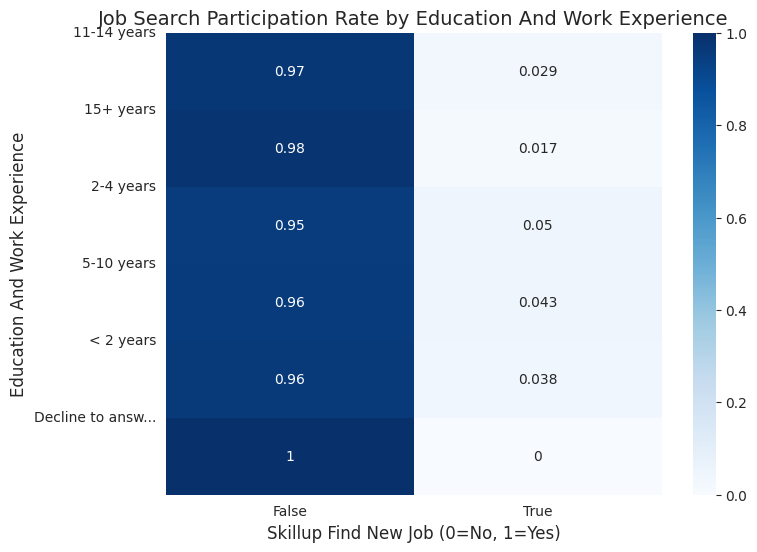

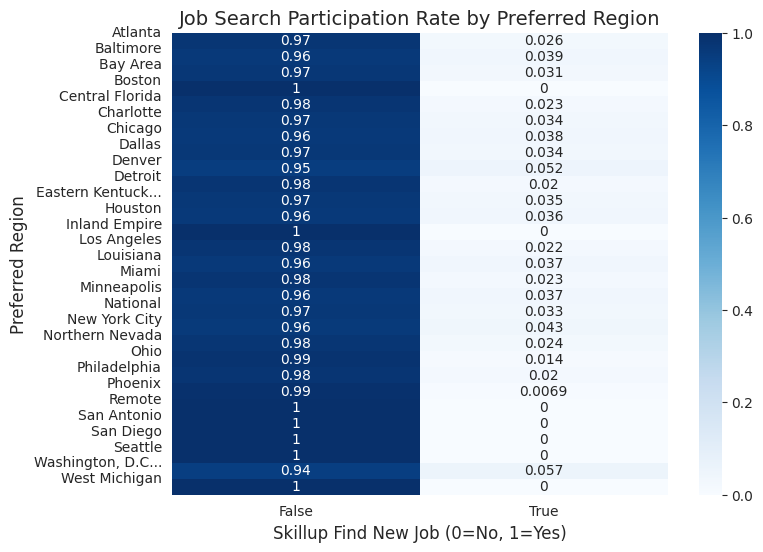

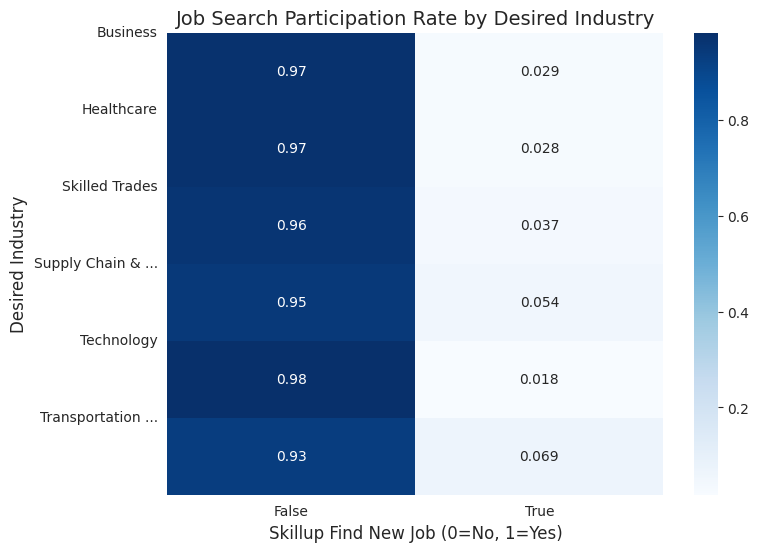

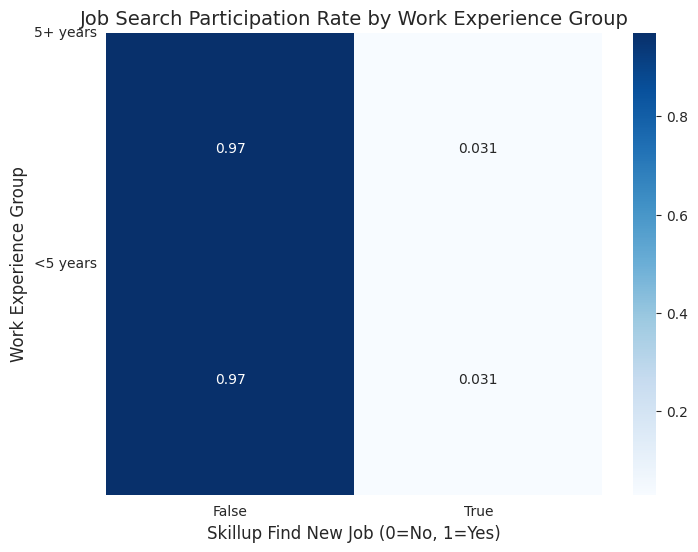

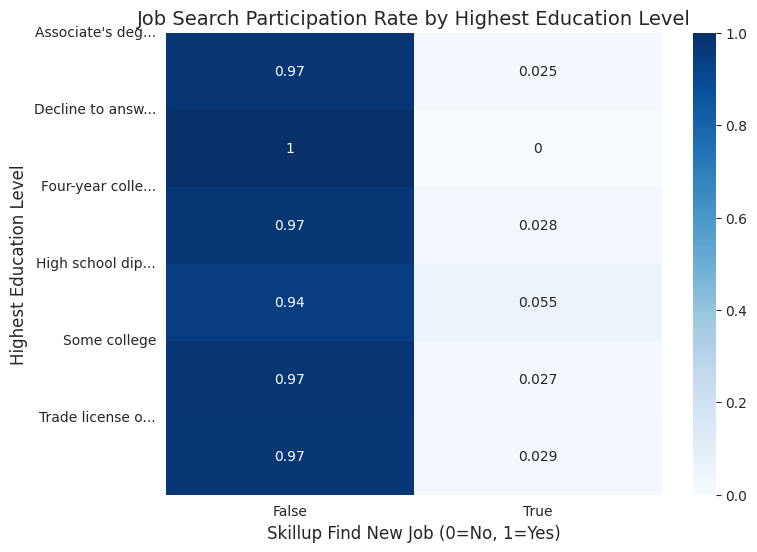

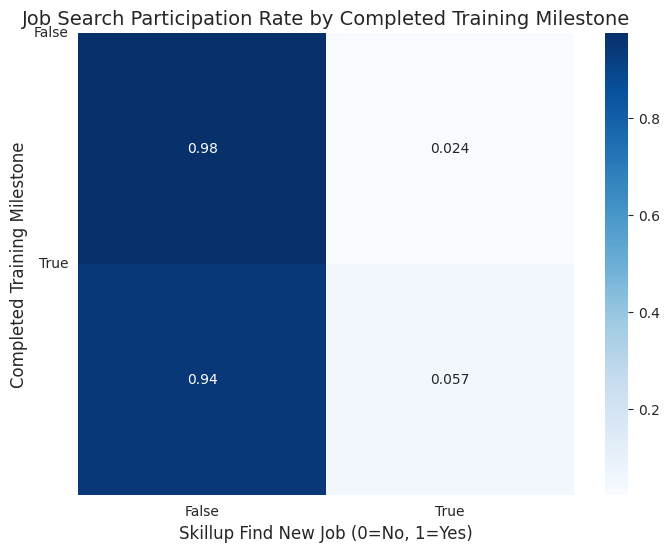

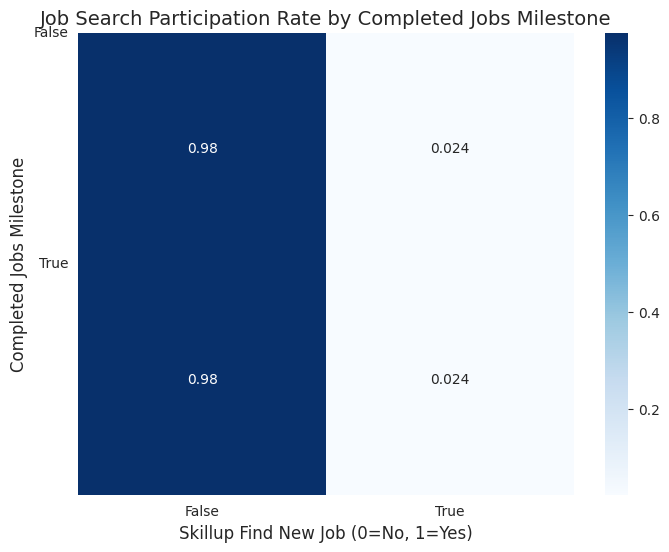

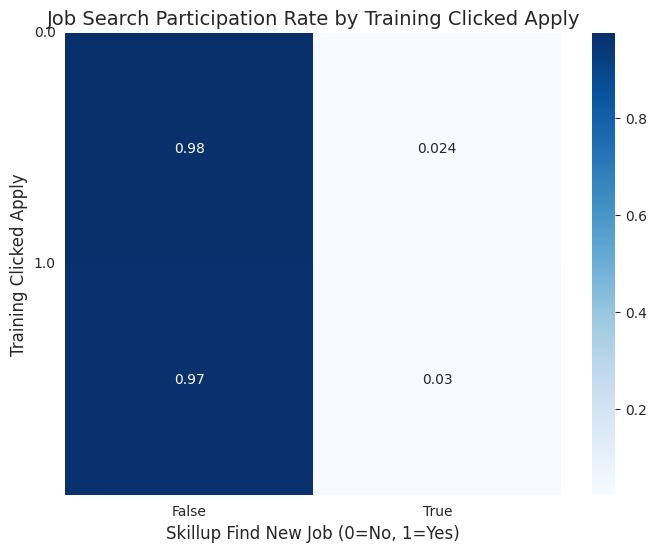

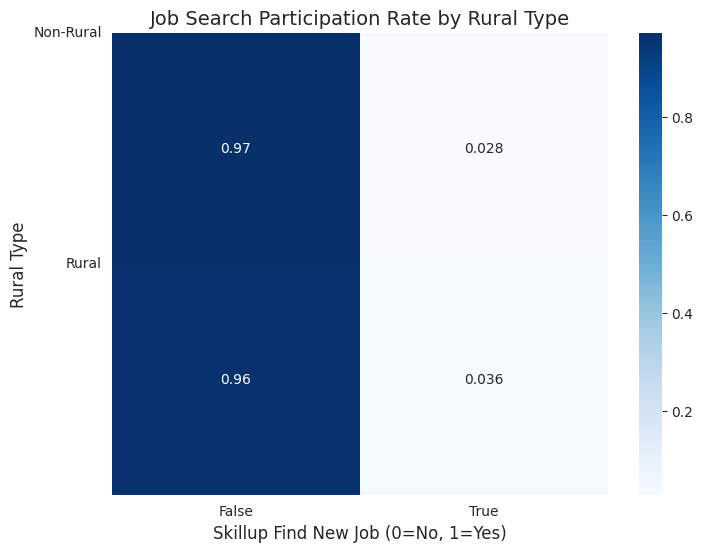

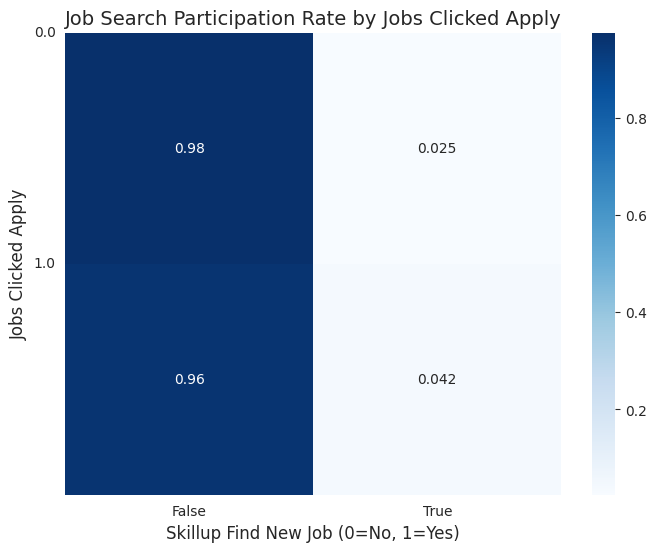

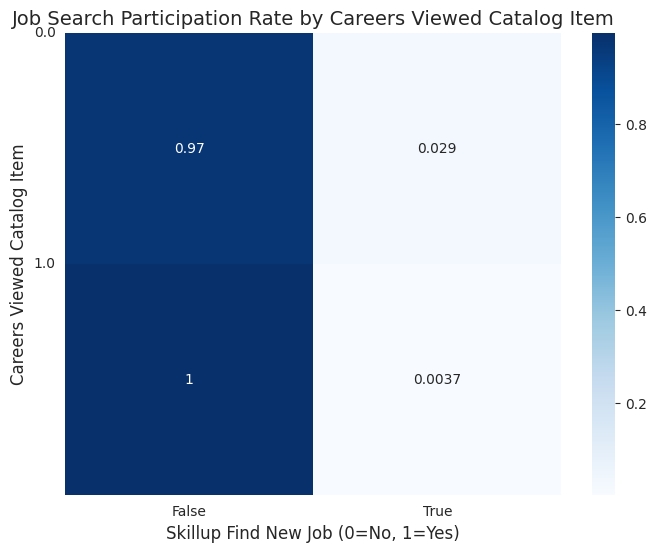

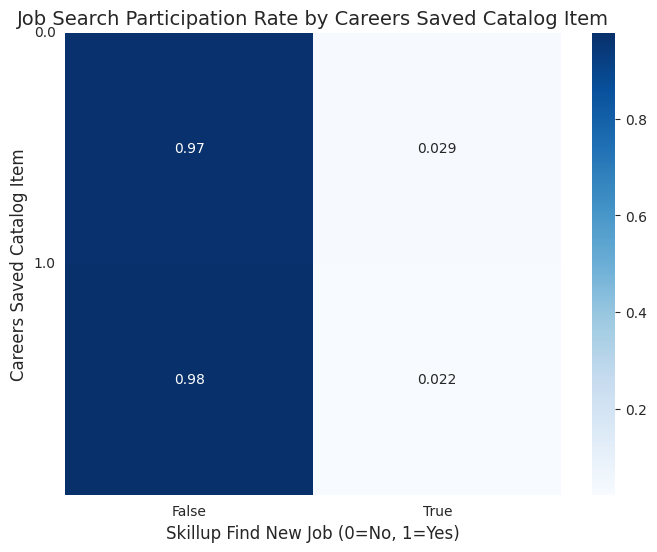

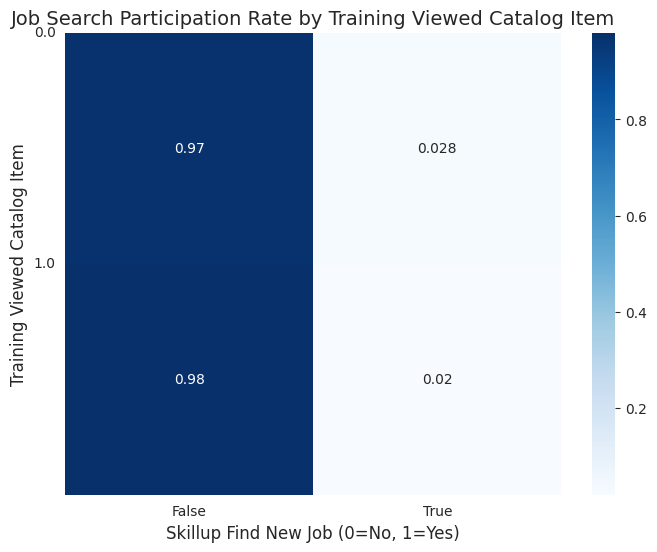

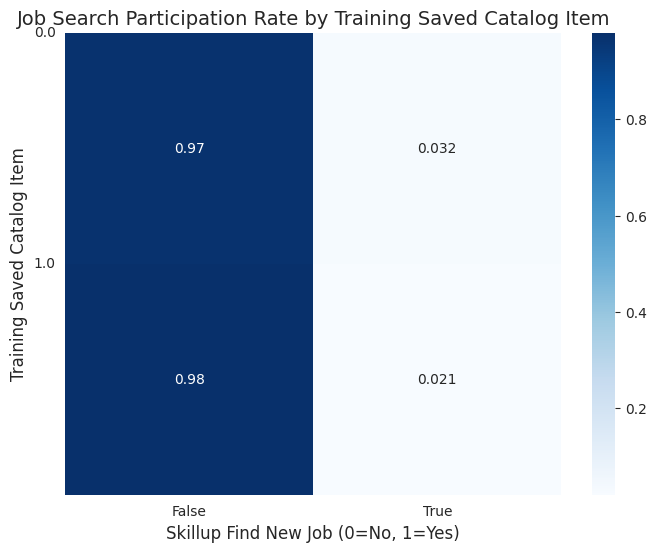

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define categorical features
categorical_features = [
    'Race', 'Gender', 'Education And Work Experience', 'Preferred Region',
    'Desired Industry', 'Work Experience Group', 'Highest Education Level',
    'Completed Training Milestone', 'Completed Jobs Milestone', 'Training Clicked Apply',
    'Rural Type', 'Jobs Clicked Apply', 'Careers Viewed Catalog Item',
    'Careers Saved Catalog Item', 'Training Viewed Catalog Item', 'Training Saved Catalog Item'
]

# Generate individual heatmaps
for feature in categorical_features:
    plt.figure(figsize=(8, 6))  # Set individual figure size

    crosstab = pd.crosstab(df[feature], df['skillup_find_new_job'], normalize='index')

    # Create heatmap
    sns.heatmap(crosstab, annot=True, cmap="Blues")

    # Set titles and labels
    plt.title(f"Job Search Participation Rate by {feature}", fontsize=14)
    plt.xlabel("Skillup Find New Job (0=No, 1=Yes)", fontsize=12)
    plt.ylabel(feature, fontsize=12)

    # Adjust y-axis labels for readability
    plt.yticks(
        range(len(crosstab.index)),
        [str(label)[:15] + '...' if len(str(label)) > 15 else str(label) for label in crosstab.index],
        rotation=0
    )

    plt.show()  # Display each plot separately


Correlation with Training Participation

<ipython-input-93-bcd98266bf79>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlation.values, y=correlation.index, palette="Blues_r")


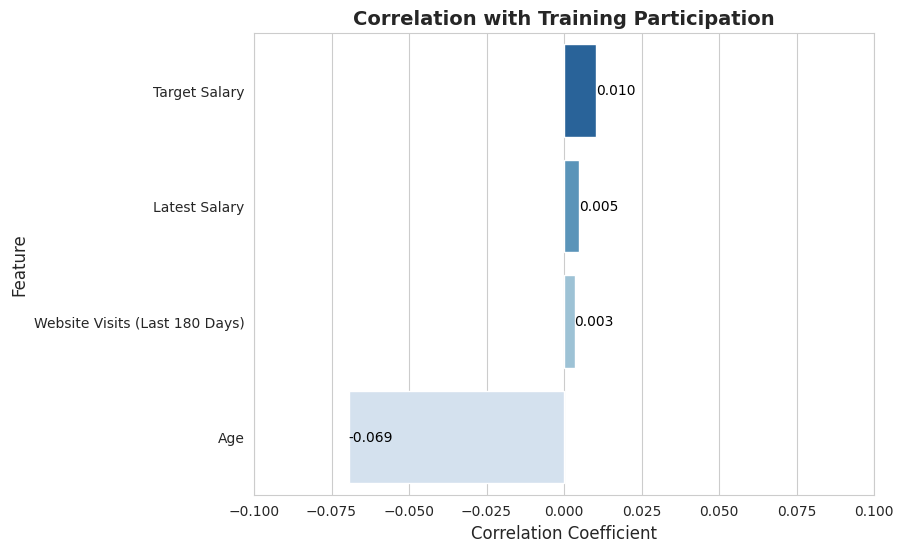

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


selected_numeric_features = ['Age', 'latestSalary', 'targetSalary', 'Website Visits (Last 180 Days)']
correlation = df[selected_numeric_features + ['skillup_training']].corr()['skillup_training'].drop('skillup_training').sort_values(ascending=False)


rename_dict = {
    'Age': 'Age',
    'latestSalary': 'Latest Salary',
    'targetSalary': 'Target Salary',
    'Website Visits (Last 180 Days)': 'Website Visits (Last 180 Days)'
}


correlation.index = correlation.index.map(rename_dict)


sns.set_style("whitegrid")


plt.figure(figsize=(8, 6))
ax = sns.barplot(x=correlation.values, y=correlation.index, palette="Blues_r")


plt.title("Correlation with Training Participation", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)


plt.xlim(-0.1, 0.1)


for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height() / 2),
               ha='left', va='center', fontsize=10, color='black')

plt.show()


Correlation with Finding New Job

<ipython-input-94-423009c8fe18>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlation.values, y=correlation.index, palette="Blues_r")


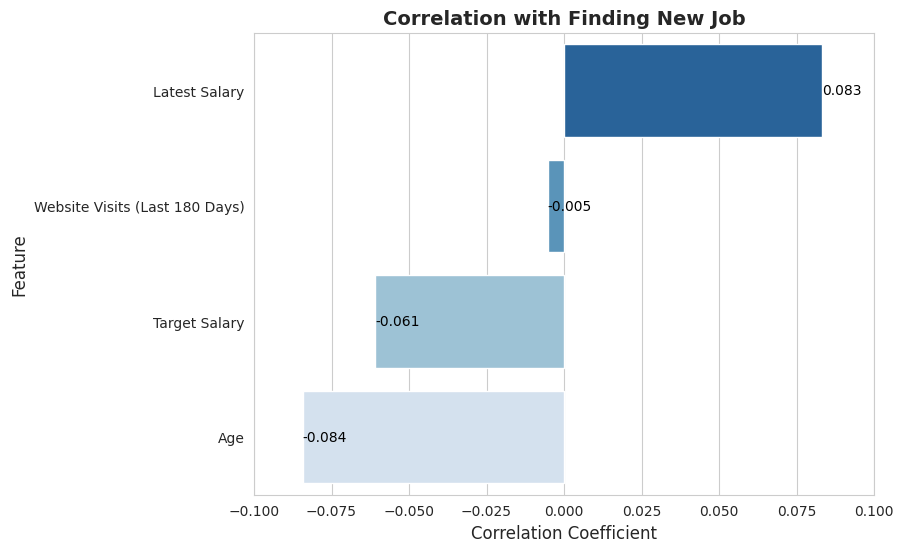

In [ ]:
selected_numeric_features = ['Age', 'latestSalary', 'targetSalary', 'Website Visits (Last 180 Days)']
correlation = df[selected_numeric_features + ['skillup_find_new_job']].corr()['skillup_find_new_job'].drop('skillup_find_new_job').sort_values(ascending=False)


rename_dict = {
    'Age': 'Age',
    'latestSalary': 'Latest Salary',
    'targetSalary': 'Target Salary',
    'Website Visits (Last 180 Days)': 'Website Visits (Last 180 Days)'
}


correlation.index = correlation.index.map(rename_dict)


sns.set_style("whitegrid")


plt.figure(figsize=(8, 6))
ax = sns.barplot(x=correlation.values, y=correlation.index, palette="Blues_r")


plt.title("Correlation with Finding New Job", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)


plt.xlim(-0.1, 0.1)


for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height() / 2),
               ha='left', va='center', fontsize=10, color='black')

plt.show()


#Prediction Model

y=skillup_training

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Define target variable
target_variable = 'skillup_training'

# Select categorical and numerical features
categorical_features = df.select_dtypes(exclude=['number', 'bool', 'datetime']).columns.tolist()

numerical_features = ['Age', 'latestSalary', 'targetSalary', 'Website Visits (Last 180 Days)']  # Numerical variables

# Convert categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical and encoded categorical features
X = pd.concat([df_encoded, df[numerical_features]], axis=1)

# Define target variable
y = df[target_variable]

# Handle missing values
X.fillna(X.median(), inplace=True)  # Fill numerical variables with median
X.fillna(X.mode().iloc[0], inplace=True)  # Fill categorical variables with mode

# Perform undersampling to balance the dataset
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Split the resampled dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Check class distribution after undersampling
balanced_class_distribution = Counter(y_resampled)

balanced_class_distribution


Counter({False: 1117, True: 1117})

Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# **1️Logistic Regression**
# -------------------------------
# Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Performance")
print(classification_report(y_test, y_pred_log))

# Extract logistic regression coefficients
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
coefs = coefs.sort_values()

# Display the top 10 most important features
print("Top 10 Most Important Features in Logistic Regression")
print(coefs.tail(10))

Logistic Regression Performance
              precision    recall  f1-score   support

       False       0.63      0.50      0.56       347
        True       0.56      0.68      0.61       324

    accuracy                           0.59       671
   macro avg       0.59      0.59      0.59       671
weighted avg       0.60      0.59      0.59       671

Top 10 Most Important Features in Logistic Regression
Desired Industry_Skilled Trades                              0.000303
Gender_Other, declined                                       0.000347
Preferred Region_New York City                               0.000445
Training Clicked Apply_1.0                                   0.000500
Highest Education Level_High school diploma or equivalent    0.000547
Education And Work Experience_2-4 years                      0.000608
Gender_Male                                                  0.000678
Desired Industry_Technology                                  0.000780
Race_Black or African Ameri

Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance")
print(classification_report(y_test, y_pred_rf))


feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

#Extract feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
top_10_features = feature_importance.nlargest(10)



print("Top 10 Most Important Features in Random Forest")
print(top_10_features)

Random Forest Performance
              precision    recall  f1-score   support

       False       0.61      0.57      0.59       347
        True       0.57      0.60      0.59       324

    accuracy                           0.59       671
   macro avg       0.59      0.59      0.59       671
weighted avg       0.59      0.59      0.59       671

Top 10 Most Important Features in Random Forest
Age                                                          0.191642
Website Visits (Last 180 Days)                               0.052761
Desired Industry_Technology                                  0.027887
Race_White                                                   0.027674
Desired Industry_Healthcare                                  0.026821
Gender_Male                                                  0.025556
Rural Type_Rural                                             0.025190
Highest Education Level_High school diploma or equivalent    0.024311
Race_Black or African American         

y=skillup_find_new_job

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Define target variable
target_variable = 'skillup_find_new_job'

# Select categorical and numerical features
categorical_features = df.select_dtypes(exclude=['number', 'bool', 'datetime']).columns.tolist()

numerical_features = ['Age', 'latestSalary', 'targetSalary', 'Website Visits (Last 180 Days)']  # Numerical variables

# Convert categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical and encoded categorical features
X = pd.concat([df_encoded, df[numerical_features]], axis=1)

# Define target variable
y = df[target_variable]

# Handle missing values
X.fillna(X.median(), inplace=True)  # Fill numerical variables with median
X.fillna(X.mode().iloc[0], inplace=True)  # Fill categorical variables with mode

# Perform undersampling to balance the dataset
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Split the resampled dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Check class distribution after undersampling
balanced_class_distribution = Counter(y_resampled)

balanced_class_distribution


Counter({False: 574, True: 574})

Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# **1️Logistic Regression**
# -------------------------------
# Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Performance")
print(classification_report(y_test, y_pred_log))

# Extract logistic regression coefficients
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
coefs = coefs.sort_values()

# Display the top 10 most important features
print("Top 10 Most Important Features in Logistic Regression")
print(coefs.tail(10))

Logistic Regression Performance
              precision    recall  f1-score   support

       False       0.73      0.66      0.69       184
        True       0.65      0.73      0.69       161

    accuracy                           0.69       345
   macro avg       0.69      0.69      0.69       345
weighted avg       0.69      0.69      0.69       345

Top 10 Most Important Features in Logistic Regression
Highest Education Level_High school diploma or equivalent    0.520520
Preferred Region_Chicago                                     0.528942
Preferred Region_New York City                               0.561208
Education And Work Experience_2-4 years                      0.581675
Gender_Male                                                  0.619004
Preferred Region_Denver                                      0.622288
Race_Middle Eastern or North African                         0.631632
Training Clicked Apply_1.0                                   0.666073
Completed Training Mileston

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance")
print(classification_report(y_test, y_pred_rf))


feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

#Extract feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
top_10_features = feature_importance.nlargest(10)


print("Top 10 Most Important Features in Random Forest")
print(top_10_features)

Random Forest Performance
              precision    recall  f1-score   support

       False       0.68      0.61      0.64       184
        True       0.60      0.68      0.64       161

    accuracy                           0.64       345
   macro avg       0.64      0.64      0.64       345
weighted avg       0.65      0.64      0.64       345

Top 10 Most Important Features in Random Forest
Age                                                          0.188075
Website Visits (Last 180 Days)                               0.045649
Gender_Male                                                  0.033985
Highest Education Level_High school diploma or equivalent    0.033685
Desired Industry_Technology                                  0.030632
Race_Black or African American                               0.028705
Desired Industry_Healthcare                                  0.027079
Education And Work Experience_5-10 years                     0.023819
Highest Education Level_Some college   

#WPAC Race/region vs. Finding jobs

In [99]:
filtered_data = df[[ 'skillup_training', 'skillup_find_new_job', 'Race',
            'Completed Career Milestone', 'Completed Jobs Milestone', 'Completed Training Milestone']]

In [100]:
race_dict = {
    0: "Asian",
    1: "Black or African American",
    2: "Decline to answer",
    3: "Hispanic or Latino",
    4: "Middle Eastern or North African",
    5: "Multiracial / Multiethnic",
    6: "Native American or Alaskan / Native Hawaiian",
    7: "White",
    8: "NaN"
}


In [101]:
def X_job_analysis(x_var):
    # Ensure x_var exists in the DataFrame
    if x_var not in df.columns:
        raise ValueError(f"Column '{x_var}' not found in the DataFrame")

    # Select relevant columns (avoid key errors)
    selected_columns = ['skillup_training', 'skillup_find_new_job', x_var,
                        'Completed Career Milestone', 'Completed Jobs Milestone',
                        'Completed Training Milestone']

    filtered_data = df[selected_columns].dropna(subset=['skillup_training', 'skillup_find_new_job'])

    # Group by x_var and compute mean for job completion metrics
    x_var_job_analysis = (
        filtered_data.groupby(x_var)[['skillup_training', 'skillup_find_new_job']]
        .mean()
        .reset_index()
    )

    # Rename columns for better readability
    x_var_job_analysis.rename(columns={
        'skillup_training': 'Training_Participation_Rate',
        'skillup_find_new_job': 'Finding_Job_through_Skillup_Rate'
    }, inplace=True)

    return x_var_job_analysis



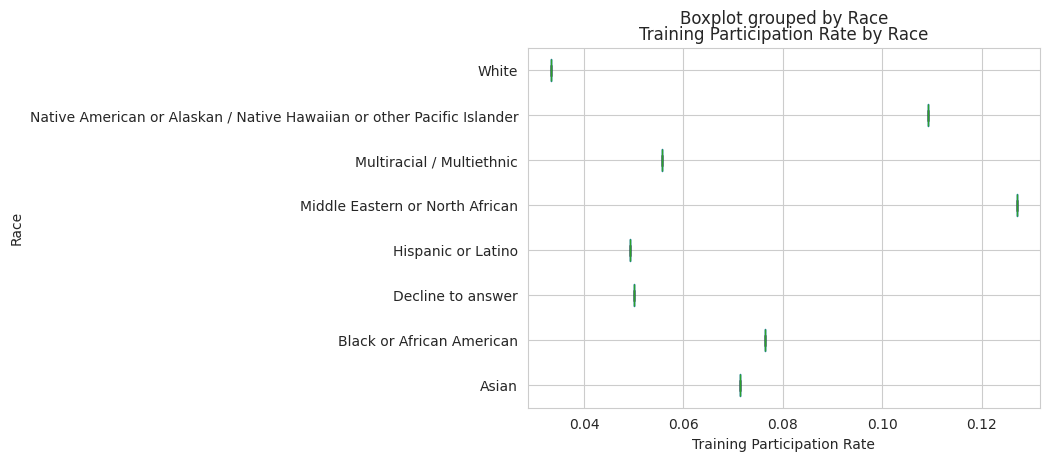

In [104]:
df_result = X_job_analysis('Race')
# Create boxplot (fix column name)
df_result.boxplot(column='Training_Participation_Rate',by='Race', vert=False)

# Set title and labels
plt.title("Training Participation Rate by Race")
plt.xlabel("Training Participation Rate")
plt.ylabel("Race")

# Show plot
plt.show()

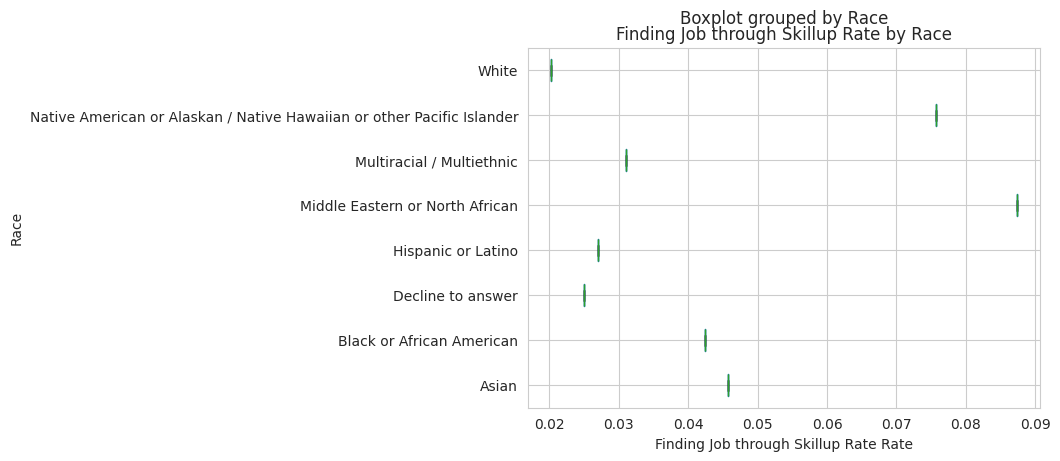

In [105]:
df_result = X_job_analysis('Race')
# Create boxplot (fix column name)
df_result.boxplot(column='Finding_Job_through_Skillup_Rate',by='Race', vert=False)

# Set title and labels
plt.title("Finding Job through Skillup Rate by Race")
plt.xlabel("Finding Job through Skillup Rate Rate")
plt.ylabel("Race")

# Show plot
plt.show()

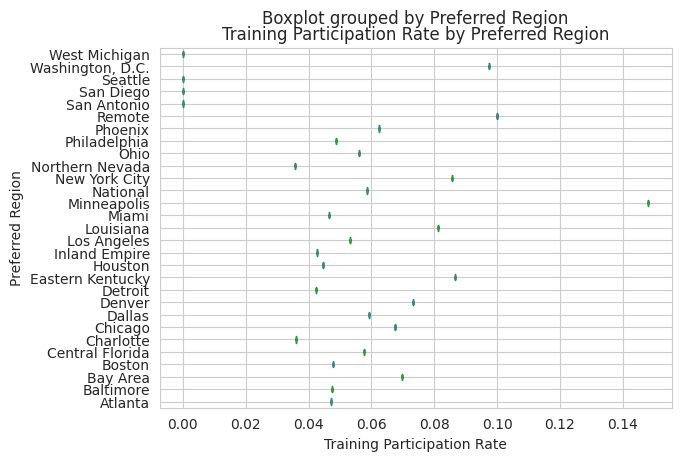

In [107]:
df_result = X_job_analysis('Preferred Region')
# Create boxplot (fix column name)
df_result.boxplot(column='Training_Participation_Rate',by='Preferred Region', vert=False)

# Set title and labels
plt.title("Training Participation Rate by Preferred Region")
plt.xlabel("Training Participation Rate")
plt.ylabel("Preferred Region")

# Show plot
plt.show()

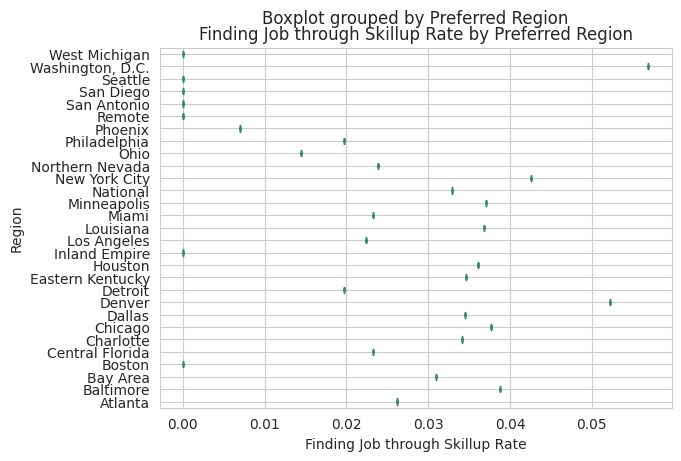

In [108]:
df_result = X_job_analysis('Preferred Region')
df_result.boxplot(column='Finding_Job_through_Skillup_Rate', by='Preferred Region', vert=False)
plt.title("Finding Job through Skillup Rate by Preferred Region")
plt.xlabel("Finding Job through Skillup Rate")
plt.ylabel("Region")
plt.show()

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Desired Industry                 12199 non-null  object        
 1   Rural Type                       17311 non-null  object        
 2   myPathCompleted                  15784 non-null  float64       
 3   Preferred Region                 18694 non-null  object        
 4   Preferred Region Group           18696 non-null  object        
 5   Education And Work Experience    13834 non-null  object        
 6   Work Experience Group            18696 non-null  object        
 7   Race                             15897 non-null  object        
 8   Highest Education Level          13593 non-null  object        
 9   latestSalary                     1782 non-null   float64       
 10  targetSalary                     1645 non-null   float64  

In [110]:
df_user_characteristics = df[df['skillup_find_new_job'] == True]

In [111]:
df_user_characteristics_false = df[df['skillup_find_new_job'] == False]

In [112]:
df_user_characteristics = df_user_characteristics[
    ['skillup_find_new_job', 'Website Visits (Last 180 Days)', 'Jobs Clicked Apply',
     'Jobs Edited Status', 'Jobs Saved Catalog Item', 'Jobs Viewed Catalog Item','Training Clicked Apply','Training Edited Status']
]

In [113]:
df_user_characteristics_false = df_user_characteristics_false[
    ['skillup_find_new_job', 'Website Visits (Last 180 Days)', 'Jobs Clicked Apply',
     'Jobs Edited Status', 'Jobs Saved Catalog Item', 'Jobs Viewed Catalog Item','Training Clicked Apply','Training Edited Status']
]

In [114]:
df_user_characteristics['Jobs Clicked Apply'].value_counts()

,count
Jobs Clicked Apply,
0.0,104
1.0,37


In [115]:
# Calculate the proportion of 1s in the 'Jobs Clicked Apply' column
proportion_1 = df_user_characteristics['Jobs Clicked Apply'].value_counts(normalize=True)[1]

print(f"The proportion of 1s in 'Jobs Clicked Apply' is: {proportion_1}")


The proportion of 1s in 'Jobs Clicked Apply' is: 0.2624113475177305


In [116]:
# Calculate the proportion of 1s in the 'Jobs Clicked Apply' column
proportion_1_false = df_user_characteristics_false['Jobs Clicked Apply'].value_counts(normalize=True)[1]

print(f"The proportion of 1s in 'Jobs Clicked Apply' is: {proportion_1}")

The proportion of 1s in 'Jobs Clicked Apply' is: 0.2624113475177305


The proportion of 1s in 'Jobs Clicked Apply' is: 0.2624113475177305
The proportion of 0s in 'Jobs Clicked Apply' is: 0.16941982272361


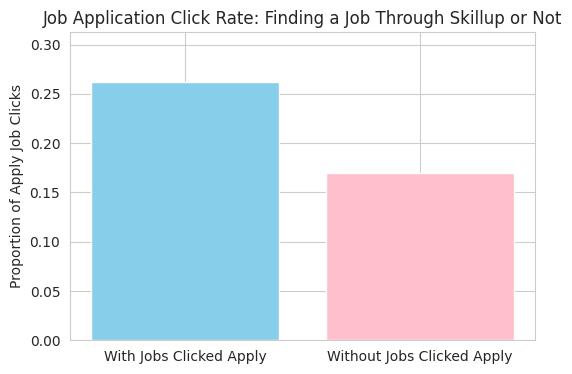

The proportion of 1s in 'Training Clicked Apply' is: 0.7471590909090909
The proportion of 0s in 'Training Clicked Apply' is: 0.6494845360824743


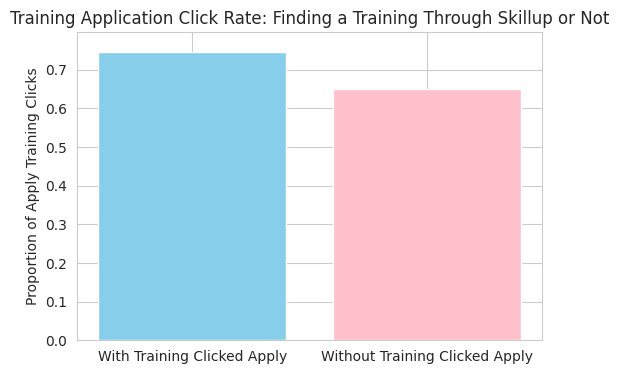

In [117]:
df_user_characteristics = df[df['skillup_find_new_job'] == True]
df_user_characteristics_false = df[df['skillup_find_new_job'] == False]
df_user_characteristics2 = df[df['skillup_training'] == True]

df_user_characteristics2_false = df[df['skillup_training'] == False]
# Calculate the proportion of 1s in the 'Jobs Clicked Apply' column
proportion_1 = df_user_characteristics['Jobs Clicked Apply'].value_counts(normalize=True)[1]

print(f"The proportion of 1s in 'Jobs Clicked Apply' is: {proportion_1}")

# Calculate the proportion of 1s in the 'Jobs Clicked Apply' column
proportion_1_false = df_user_characteristics_false['Jobs Clicked Apply'].value_counts(normalize=True)[1]

print(f"The proportion of 0s in 'Jobs Clicked Apply' is: {proportion_1_false}")
# Labels and values for the bar chart
labels = ['With Jobs Clicked Apply', 'Without Jobs Clicked Apply']
values = [proportion_1, proportion_1_false]

# Create bar plot
plt.figure(figsize=(6,4))
plt.bar(labels, values, color=['#87CEEB', 'pink'])
plt.ylabel('Proportion of Apply Job Clicks')
plt.title('Job Application Click Rate: Finding a Job Through Skillup or Not')
plt.ylim(0, max(values) + 0.05)

# Show plot
plt.show()
# Calculate the proportion of 1s in the 'Training Clicked Apply' column
proportion_2 = df_user_characteristics2['Training Clicked Apply'].value_counts(normalize=True)[1]

print(f"The proportion of 1s in 'Training Clicked Apply' is: {proportion_2}")
# Calculate the proportion of 1s in the 'Training Clicked Apply' column
proportion_2_false = df_user_characteristics2_false['Training Clicked Apply'].value_counts(normalize=True)[1]

print(f"The proportion of 0s in 'Training Clicked Apply' is: {proportion_2_false}")
# Labels and values for the bar chart
labels = ['With Training Clicked Apply', 'Without Training Clicked Apply']
values = [proportion_2, proportion_2_false]

# Create bar plot
plt.figure(figsize=(6,4))
plt.bar(labels, values, color=['#87CEEB','pink'])
plt.ylabel('Proportion of Apply Training Clicks')
plt.title('Training Application Click Rate: Finding a Training Through Skillup or Not')
plt.ylim(0, max(values) + 0.05)

# Show plot
plt.show()